In [1]:
from datetime import datetime
import importlib
import numpy as np
from cpuinfo import get_cpu_info
import Analysis.visualization as visualization
from Engine.map_loader import MapLoader
from Engine.masks import layer_map

importlib.reload(visualization)
VisualTool = visualization.VisualTool

In [2]:
vis=VisualTool(show=True, size=(10,10), save=True, dpi=100, save_dir="__RESULTS__/_plots", save_title=False)

### Overview of Construction site map

In [3]:
map=MapLoader().load("gangjin/full")

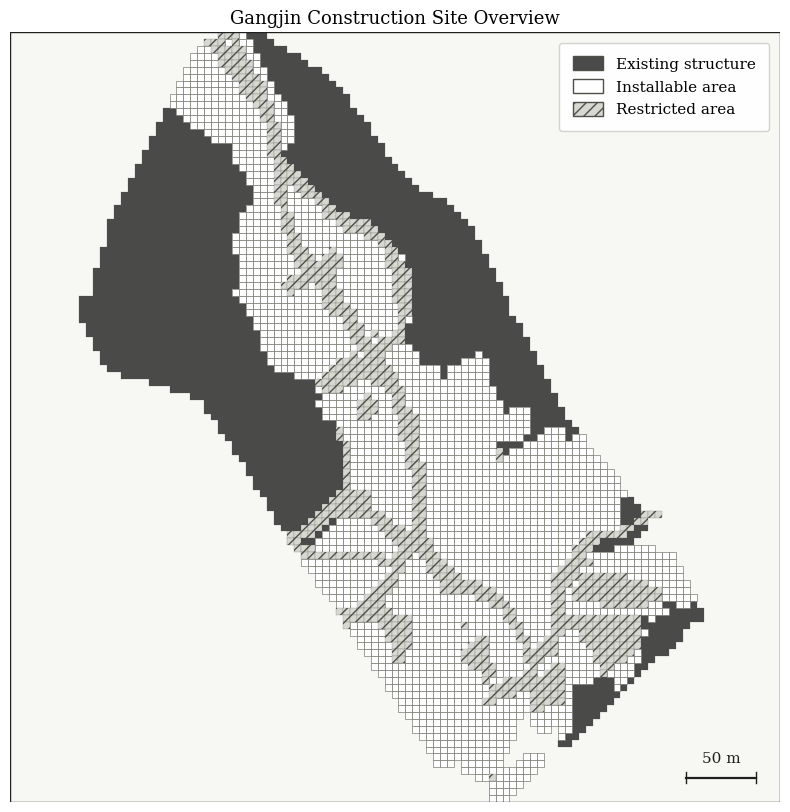

Saved figure: __RESULTS__/_plots/06-19-13-41/construction_map_overview.png


In [4]:
vis.showMapOverview(map_data=map, title="Gangjin Construction Site Overview", filename="construction_map_overview")

Installable map
<br><sub> A binary grid mask that defines physically feasible sensor deployment locations on the site. </sub>

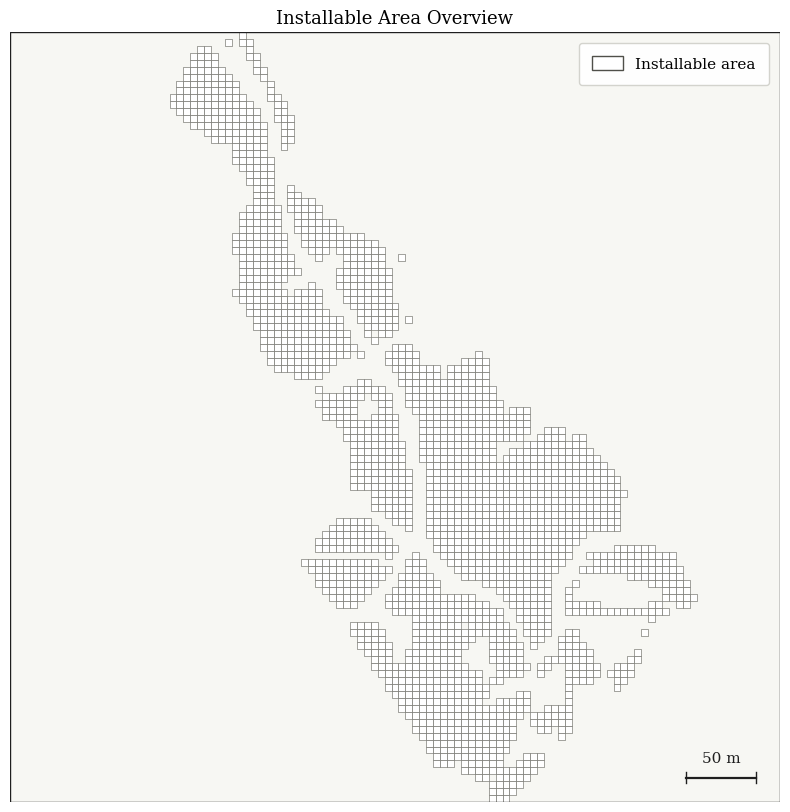

Saved figure: __RESULTS__/_plots/06-19-13-41/installable_map_overview.png


In [5]:
installable_layer = layer_map(map, keep_values=[2])
vis.showMapOverview(
    map_data=installable_layer,
    title="Installable Area Overview",
    filename="installable_map_overview",
    zone_style="installable",
)

Uninstallable map
<br><sub>Regions excluded from sensor deployment due to safety, accessibility, or operational constraints <br>(e.g., equipment routes, waterlogged areas, vegetation, and offices).</sub>

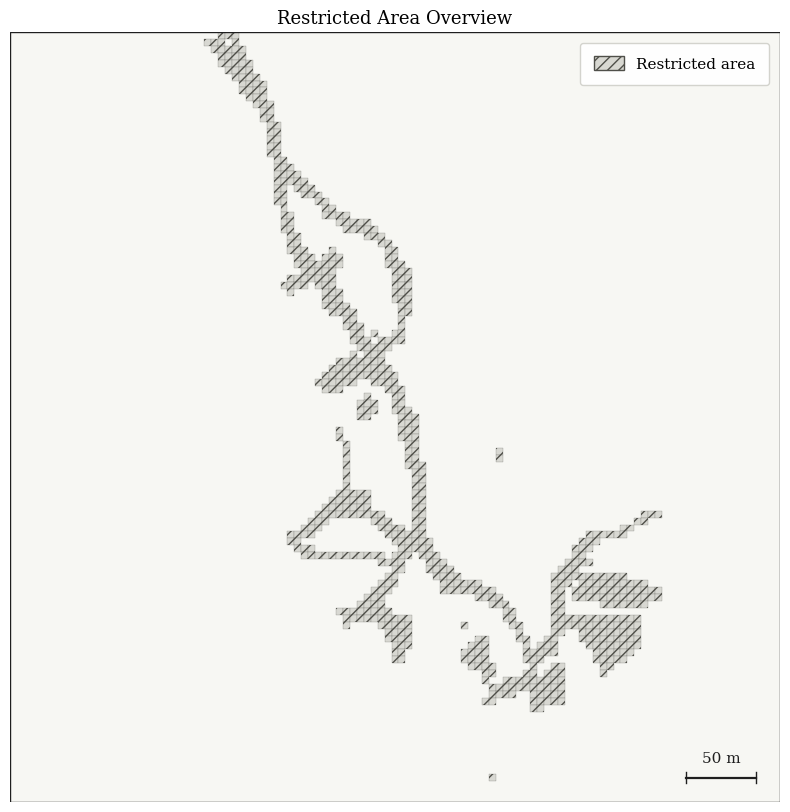

Saved figure: __RESULTS__/_plots/06-19-13-41/restricted_map_overview.png


In [6]:
road_layer = layer_map(map, keep_values=[3])
vis.showMapOverview(
    map_data=road_layer,
    title="Restricted Area Overview",
    filename="restricted_map_overview",
    zone_style="restricted",
)

Jobsite area
<br><sub>The coverage target area for sensor deployment, defined as the union of installable and non-installable regions.</sub>

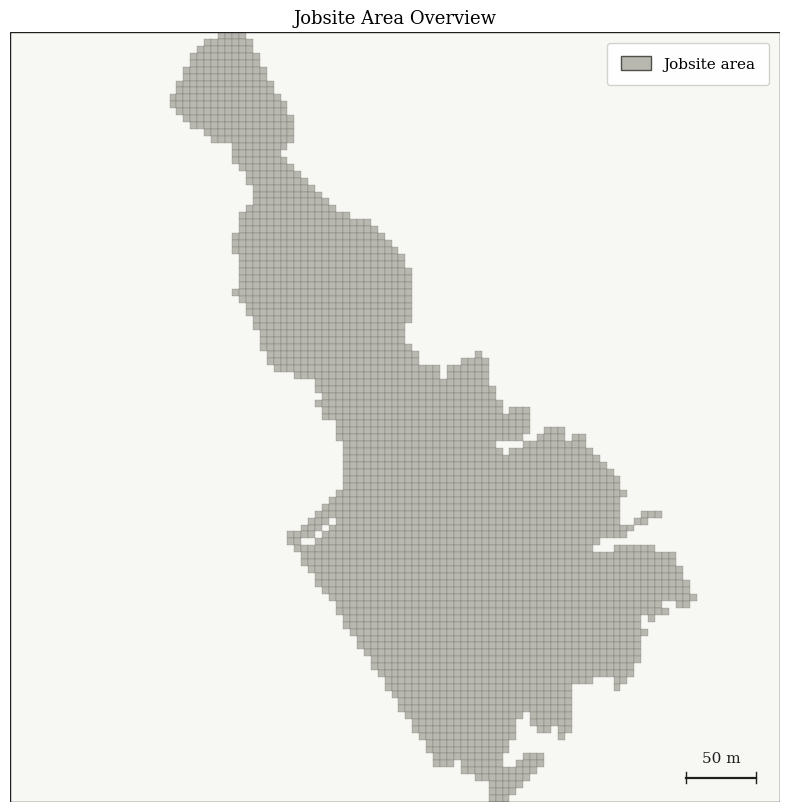

Saved figure: __RESULTS__/_plots/06-19-13-41/jobsite_map_overview.png


In [7]:
jobsite_layer = layer_map(map, keep_values=[2,3])
vis.showMapOverview(
    map_data=jobsite_layer,
    title="Jobsite Area Overview",
    filename="jobsite_map_overview",
    zone_style="jobsite",
)

### Systematic sensor deployment

In [8]:
#Set sensor coverage radius
COVERAGE = 45

Outermost corner location candidate extraction
<br><sub> Detection of outermost feasible sensor placement candidates within installable regions, since environmental sensing modules must be deployed at the site boundaries to capture extreme conditions. </sub>

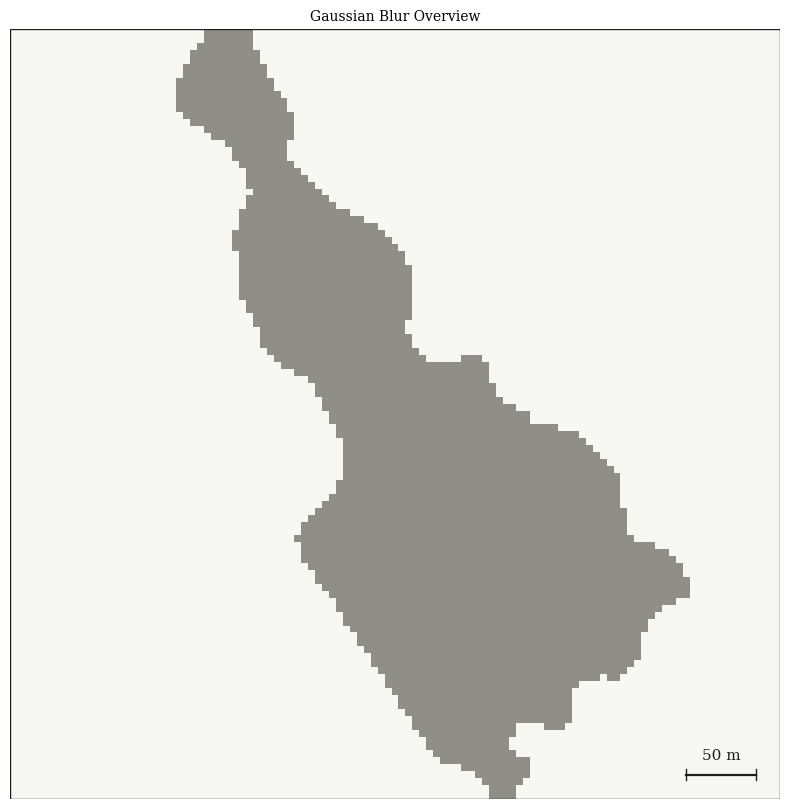

Saved figure: __RESULTS__/_plots/06-19-13-41/gaussian_blur_map_overview.png


In [9]:
from OuterDeployment.HarrisCorner import HarrisCorner

corner_instance = HarrisCorner(jobsite_layer)

blur_map = corner_instance.gaussianBlur(grid=jobsite_layer)
vis.showMapOverview(
    map_data=blur_map,
    base_map=map,
    title="Gaussian Blur Heatmap Overview",
    filename="gaussian_blur_map_overview",
    zone_style="heatmap_overlay",
    overlay_alpha=0.75,
    overlay_percentile=99.0,
    overlay_threshold_percentile=None,
    overlay_spread=0,
    overlay_gamma=1.0,
    overlay_cmap="YlOrRd",
)

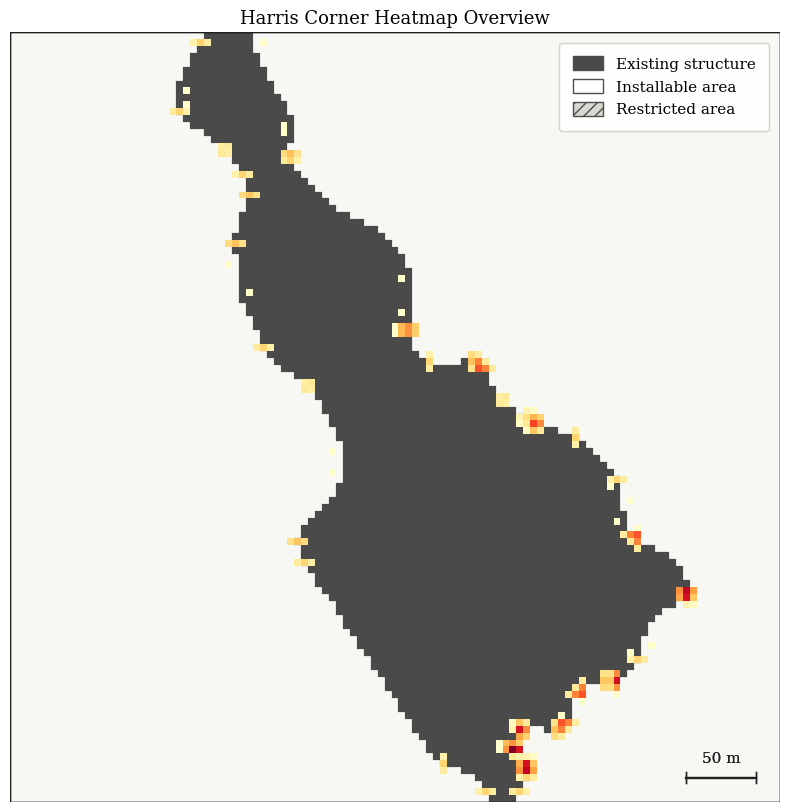

Saved figure: __RESULTS__/_plots/06-19-13-41/harris_corner_heatmap_overview.png


In [10]:
corner_heatmap = corner_instance.harrisCorner(
                                                grid=blur_map,
                                                block_size=3,
                                                ksize=3,
                                                k=0.05
                                                )
vis.showMapOverview(
    map_data=corner_heatmap,
    base_map=map,
    title="Harris Corner Heatmap Overview",
    filename="harris_corner_heatmap_overview",
    zone_style="harris_corner",
    overlay_alpha=1.0,
    overlay_percentile=99.0,
    overlay_threshold_percentile=None,
    overlay_spread=0,
    overlay_gamma=0.6,
    overlay_cmap="Reds",
)

Total outermost sensors : 8


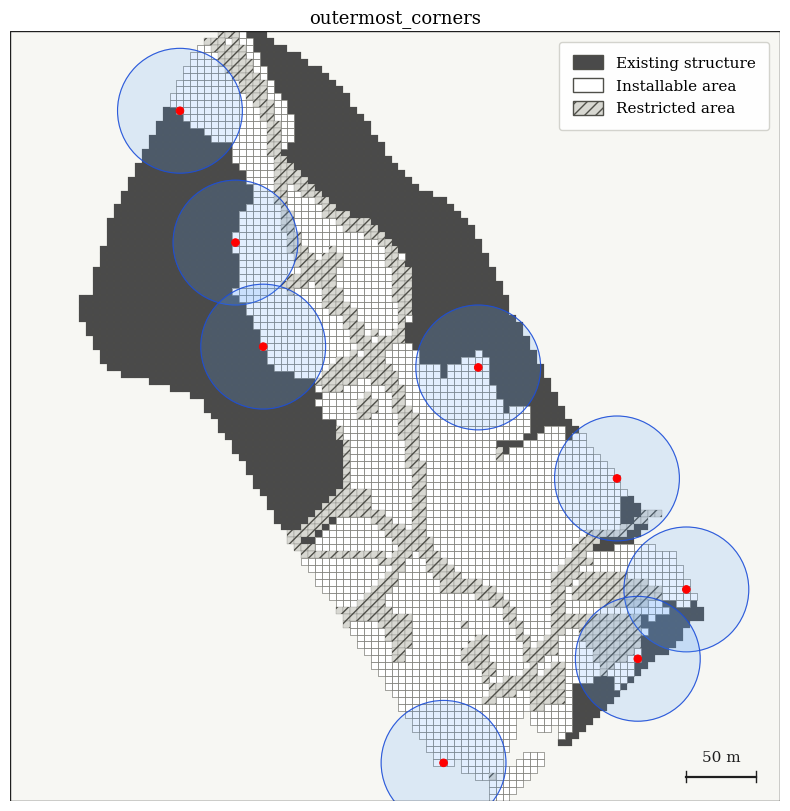

Saved figure: __RESULTS__/_plots/06-19-13-41/corner_sensors.png


In [11]:
corners = corner_instance.LMX(harris_map=corner_heatmap, installable_map=installable_layer, min_dist=9)

print("Total outermost sensors :",len(corners))
vis.showMap_circle(
    map_data=map,
    sensor_positions=corners, 
    title="outermost_corners",
    cmap="gray",
    filename="corner_sensors"
    )

Outmost corner points: 8


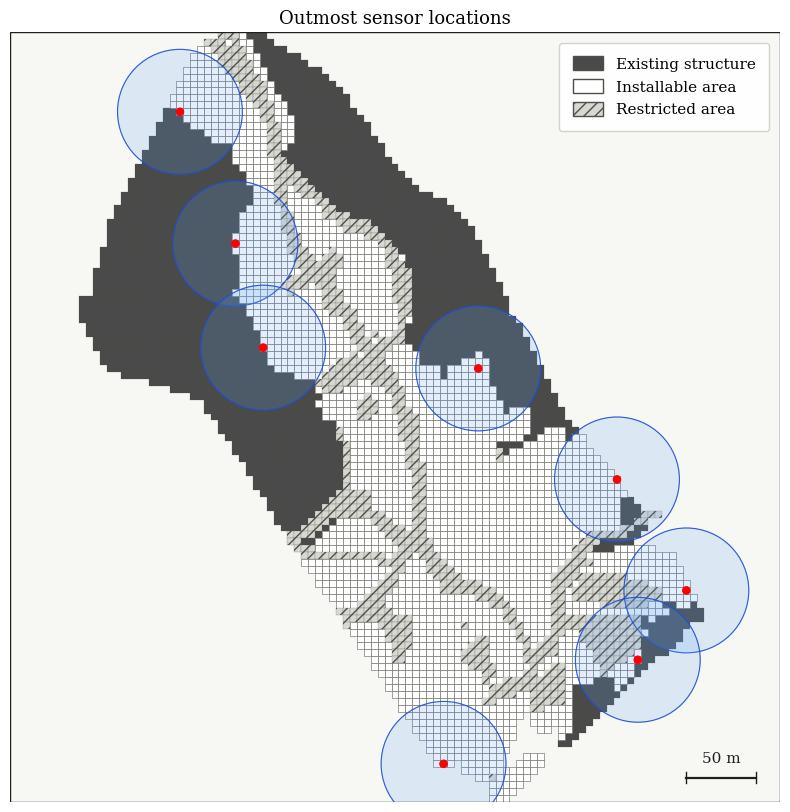

Saved figure: __RESULTS__/_plots/06-19-13-41/corner_sensors.png


In [12]:
corner_layer = HarrisCorner(jobsite_layer)
corner_candidate = corner_layer.run(
    grid=jobsite_layer,                
    installable_layer=installable_layer, 
    blockSize=3,
    ksize=3,
    k=0.05,
    dilate_size=5,
    min_dist=9,
)

print("Outmost corner points:", len(corner_candidate))
vis.showMap_circle(map_data=map, sensor_positions=corner_candidate, title="Outmost sensor locations",radius=COVERAGE, cmap='gray', filename="corner_sensors")

Inner-Deployment Strategy: Greedy Search
<br><sub>Greedy search is used to place inner sensors by repeatedly selecting the installable location with the largest marginal coverage gain while preserving the same preprocessing flow.</sub>

In [13]:
from InnerDeployment.Greedy.main import SensorGreedy

greedy = SensorGreedy(
                installable_map=installable_layer,
                jobsite_map=jobsite_layer,
                coverage=COVERAGE,
                corner_positions=corner_candidate,
                min_sensors=0,
                max_sensors=140,
                candidate_stride=1,
                fitness_kwargs={"target_coverage": 100.0},
            )

optimized_result = greedy.run(
                    target_coverage=100.0,
                    max_sensors=140,
                    return_best_only=True
                )

[Greedy 000] sensors=0 / coverage=27.43% (target=100.00%)
[Greedy 001] sensors=1 / coverage=36.15% (target=100.00%)
[Greedy 002] sensors=2 / coverage=44.87% (target=100.00%)
[Greedy 003] sensors=3 / coverage=53.45% (target=100.00%)
[Greedy 004] sensors=4 / coverage=61.51% (target=100.00%)
[Greedy 005] sensors=5 / coverage=69.06% (target=100.00%)
[Greedy 006] sensors=6 / coverage=75.12% (target=100.00%)
[Greedy 007] sensors=7 / coverage=80.88% (target=100.00%)
[Greedy 008] sensors=8 / coverage=85.01% (target=100.00%)
[Greedy 009] sensors=9 / coverage=89.11% (target=100.00%)
[Greedy 010] sensors=10 / coverage=92.90% (target=100.00%)
[Greedy 011] sensors=11 / coverage=94.49% (target=100.00%)
[Greedy 012] sensors=12 / coverage=95.76% (target=100.00%)
[Greedy 013] sensors=13 / coverage=97.21% (target=100.00%)
[Greedy 014] sensors=14 / coverage=98.55% (target=100.00%)
[Greedy 015] sensors=15 / coverage=99.07% (target=100.00%)
[Greedy 016] sensors=16 / coverage=99.14% (target=100.00%)
[Greedy

In [14]:
print("[FINALIZE OUTPUT] greedy.best_solution =", greedy.best_solution)
print("[FINALIZE OUTPUT] len(greedy.best_solution) =", len(greedy.best_solution))
print("[FINALIZE OUTPUT] greedy.corner_points =", greedy.corner_points)
print("[FINALIZE OUTPUT] len(greedy.corner_points) =", len(greedy.corner_points))

[FINALIZE OUTPUT] greedy.best_solution = [(47, 63), (61, 74), (49, 87), (39, 36), (64, 91), (38, 76), (42, 51), (29, 15), (62, 63), (72, 77), (23, 0), (64, 106), (32, 30), (50, 72), (49, 96), (64, 54), (39, 85), (47, 41), (70, 98), (58, 83), (54, 57), (58, 98)]
[FINALIZE OUTPUT] len(greedy.best_solution) = 22
[FINALIZE OUTPUT] greedy.corner_points = [(14, 11), (22, 30), (26, 45), (57, 48), (77, 64), (87, 80), (80, 90), (52, 105)]
[FINALIZE OUTPUT] len(greedy.corner_points) = 8


Total number of Sensor : 30


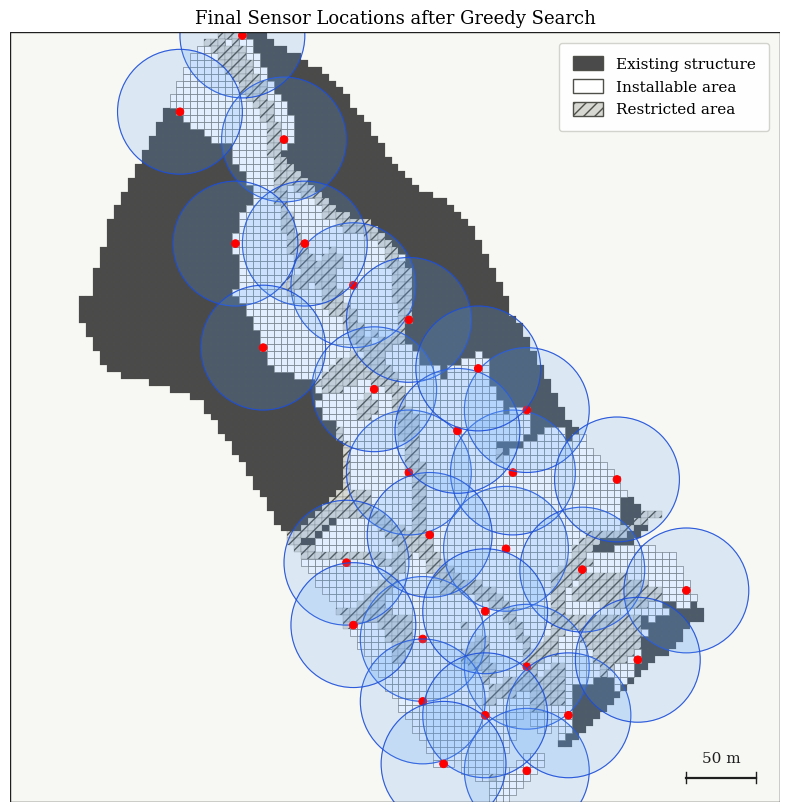

Saved figure: __RESULTS__/_plots/06-19-13-41/[GREEDY]final_result.png


In [ ]:
final_result = optimized_result + corner_candidate
print("Total number of Sensor :", len(final_result))
vis.showMap_circle(
    map_data=map,
    sensor_positions=final_result,
    title="Final Sensor Locations after Greedy Search",
    radius=COVERAGE,
    cmap='gray',
    filename="[GREEDY]final_result"
    )